# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

In [2]:
pd.set_option("display.max_columns", None)

# Load Data

In [3]:
products_df = pd.read_csv("../data/products_kaggle.csv")

In [4]:
products_df.head()

,Unnamed: 0,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


# Data Cleaning

In [5]:
products = products_df.copy()

In [6]:
predictor = ['price_usd']
features = ['brand_name', 'size', 'ingredients', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive'
            , 'highlights', 'primary_category', 'secondary_category']

# Check for Duplicates

In [7]:
products.duplicated().sum()

np.int64(0)

In [8]:
products.duplicated(subset=['product_id']).sum()

np.int64(0)

# Check for Missing Values

In [9]:
products[predictor + features].isna().sum()

price_usd                0
brand_name               0
size                  1631
ingredients            945
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
dtype: int64

In [10]:
new_products = products[predictor + features].dropna()

In [11]:
new_products.shape

(5056, 12)

# Feature Engineering

In [12]:
new_products["primary_category"].value_counts()

primary_category
Skincare           1706
Makeup             1218
Hair                984
Fragrance           702
Bath & Body         246
Mini Size           188
Men                  11
Tools & Brushes       1
Name: count, dtype: int64

In [13]:
new_products["primary_category"] = new_products["primary_category"].astype(str).str.strip()

In [14]:
if "brand_name" in new_products.columns:
       new_products["brand_name"] = new_products["brand_name"].astype(str).str.strip().str.title()

In [15]:
INGREDIENT_FLAGS = {
        "has_retinol":       r"retinol|retinoid|tretinoin|retinal\b",
        "has_niacinamide":   r"niacinamide|nicotinamide",
        "has_hyaluronic":    r"hyaluronic acid|sodium hyaluronate",
        "has_vitamin_c":     r"ascorbic acid|vitamin c|l-ascorbic|ascorbyl",
        "has_aha_bha":       r"glycolic acid|lactic acid|salicylic acid|mandelic acid|"
                              r"tartaric acid|malic acid|citric acid|aha|bha",
        "has_peptides":      r"peptide|palmitoyl|matrixyl|argireline|acetyl",
        "has_spf":           r"\bspf\b|sunscreen|zinc oxide|titanium dioxide|"
                              r"avobenzone|octinoxate",
        "has_fragrance":     r"\bfragrance\b|\bparfum\b|\bperfume\b",
        "has_alcohol":       r"alcohol denat|sd alcohol|denatured alcohol",
        "has_ceramides":     r"ceramide",
        "has_collagen":      r"collagen|hydrolyzed collagen",
        "has_bakuchiol":     r"bakuchiol",
        "has_vitamin_e":     r"tocopherol|vitamin e",
    }
 

ing = new_products["ingredients"].fillna("").astype(str).str.lower()
for flag, pattern in INGREDIENT_FLAGS.items():
    new_products[flag] = ing.str.contains(pattern, regex=True, na=False).astype(int)
    n = new_products[flag].sum()
    print(f"      {flag:<25}: {n:,} products ({n/len(new_products):.1%})")

      has_retinol              : 80 products (1.6%)
      has_niacinamide          : 394 products (7.8%)
      has_hyaluronic           : 1,195 products (23.6%)
      has_vitamin_c            : 643 products (12.7%)
      has_aha_bha              : 1,985 products (39.3%)
      has_peptides             : 717 products (14.2%)
      has_spf                  : 1,293 products (25.6%)
      has_fragrance            : 2,420 products (47.9%)
      has_alcohol              : 795 products (15.7%)
      has_ceramides            : 221 products (4.4%)
      has_collagen             : 99 products (2.0%)
      has_bakuchiol            : 56 products (1.1%)
      has_vitamin_e            : 1,865 products (36.9%)


In [16]:
new_products['size'].value_counts()

size
1.7 oz/ 50 mL      361
1 oz/ 30 mL        306
0.5 oz/ 15 mL      129
3.4 oz/ 100 mL     120
1.7 oz / 50 mL     110
                  ... 
30 mL/ 1 oz          1
.3 oz / 9 mL         1
0.1 oz / 2.8 g       1
1.35 oz/40 mL        1
.11 oz / 3.2 mL      1
Name: count, Length: 1626, dtype: int64

In [18]:
import re
import numpy as np

def extract_ml(text):
    """
    Extract size in mL from any volume/weight unit.
    Converts fl oz and oz → mL. Leaves g as-is (approx 1g ≈ 1mL for creams).
    Returns 0.0 if the product is a count item or unparseable.
    """
    if pd.isna(text):
        return 0.0
    s = str(text).lower().strip()

    # Skip count-based products entirely — return 0 so size_count handles them
    if re.search(r"[\d\.]+\s*(?:count|capsule|tablet|piece|ct\.?)", s):
        return 0.0

    # mL (no conversion needed)
    ml_match = re.search(r"([\d\.]+)\s*ml", s)
    if ml_match:
        return float(ml_match.group(1))

    # fl oz → mL (must check before plain oz)
    floz_match = re.search(r"([\d\.]+)\s*fl\.?\s*oz", s)
    if floz_match:
        return round(float(floz_match.group(1)) * 29.5735, 2)

    # oz → mL
    oz_match = re.search(r"([\d\.]+)\s*oz", s)
    if oz_match:
        return round(float(oz_match.group(1)) * 29.5735, 2)

    # g (treat as mL — reasonable for creams/powders)
    g_match = re.search(r"([\d\.]+)\s*g\b", s)
    if g_match:
        return float(g_match.group(1))
    
    slash_match = re.search(r"([\d\.]+)\s*/\s*([\d\.]+)", s)
    if slash_match:
        a, b = float(slash_match.group(1)), float(slash_match.group(2))
        return max(a, b)

    return 0.0


def extract_count(text):
    """
    Extract numeric count for count-based products.
    Returns 0.0 if volume/weight based or unparseable.
    """
    if pd.isna(text):
        return 0.0
    s = str(text).lower().strip()

    # Pattern 1: "N x Item" (e.g. "6 x Eye Masks")
    x_match = re.search(r"([\d\.]+)\s*x\s+\w+", s)
    if x_match:
        return float(x_match.group(1))
    
    slash_count_match = re.search(r"([\d\.]+)\s*/\s*[a-z]", s)
    if slash_count_match:
        return float(slash_count_match.group(1))

    # Pattern 2: explicit count-like units (expanded)
    count_match = re.search(
        r"([\d\.]+)\s*"
        r"(?:count|capsule|capsules|tablet|tablets|piece|pieces|ct\.?|"
        r"pad|pads|wipe|wipes|mask|masks|treatment|treatments|textured towels|individual masks|"
        r"sponge|sponges|pair|pairs|roller|rollers|vials|patches|"
        r"towel|towels|ampoule|ampoules|refill|refills|"
        r"pack|packs|daily pack|daily packs|healing dots|microneedling|stick packs|"
        r"softgel|softgels|soft gel|soft gels|"
        r"gummy|gummies|gummy heart|gummy hearts|"
        r"berry gummy|tangerine|"
        r"vegetarian capsule|vegetarian capsules|"
        r"vegan capsule|vegan capsules|vegan softgel|vegan softgels|"
        r"vegan gummy|vegan gummies|vegan berry|"
        r"week supply|day supply|day\b)",
        s
    )
    if count_match:
        return float(count_match.group(1))

    return 0.0


# Apply
new_products["size_ml"]    = new_products["size"].apply(extract_ml)
new_products["size_count"] = new_products["size"].apply(extract_count)

# ── Checks ───────────────────────────────────────────────────────────────────

size_cols = ["size_ml", "size_count"]
print("Products per size type:")
for c in size_cols:
    n = (new_products[c] > 0).sum()
    print(f"  {c:<20}: {n:,} ({n/len(new_products):.1%})")

# Should be zero — no product should have both a volume and a count
both = ((new_products["size_ml"] > 0) & (new_products["size_count"] > 0)).sum()
print(f"\nProducts with both size_ml and size_count > 0 (should be 0): {both}")

# Unparseable — neither column got a value, but size field exists
neither = (
    new_products["size"].notna() &
    (new_products["size_ml"] == 0) &
    (new_products["size_count"] == 0)
)
print(f"\nUnparseable (has size string but neither column filled): {neither.sum()}")
print(new_products[neither]["size"].value_counts().head(20).to_string())

Products per size type:
  size_ml             : 4,921 (97.3%)
  size_count          : 176 (3.5%)

Products with both size_ml and size_count > 0 (should be 0): 48

Unparseable (has size string but neither column filled): 7
size
Standard                            2
Original                            1
Value Size - Home and Away Kit      1
Clearly Corrective Dark Spot Duo    1
Mini Nude Eyeshadow Palette         1
Mini NuFace / Sunset Blush          1


In [22]:
new_products['log_price'] = np.log(new_products['price_usd'])

# EDA

Text(0.5, 0, 'Price (USD)')

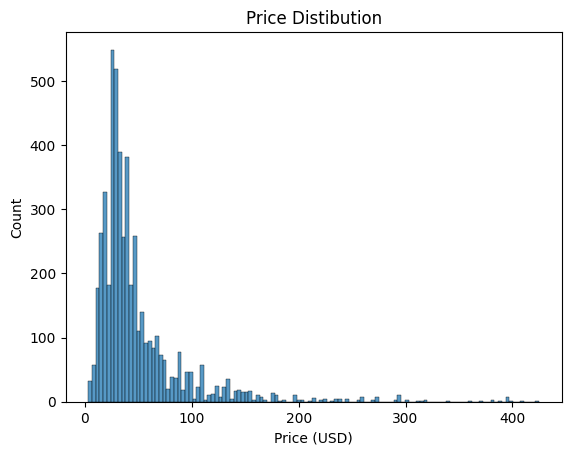

In [19]:
# Outcome Distribution
sns.histplot(new_products["price_usd"])
plt.title("Price Distibution")
plt.xlabel("Price (USD)")

Right skewed distribution --> log transformation to make more normal

Text(0.5, 0, 'log(Price (USD))')

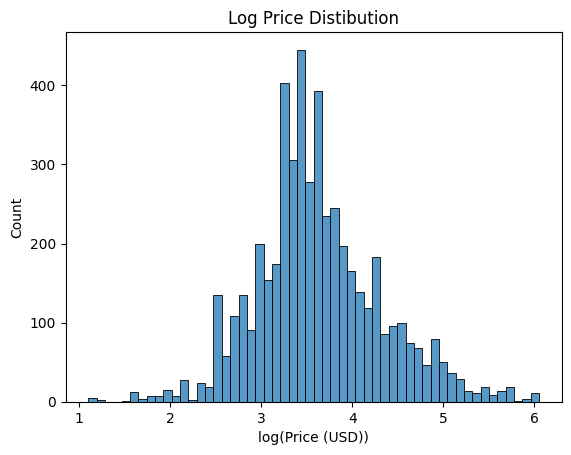

In [20]:
sns.histplot(np.log(new_products["price_usd"]))
plt.title("Log Price Distibution")
plt.xlabel("log(Price (USD))")

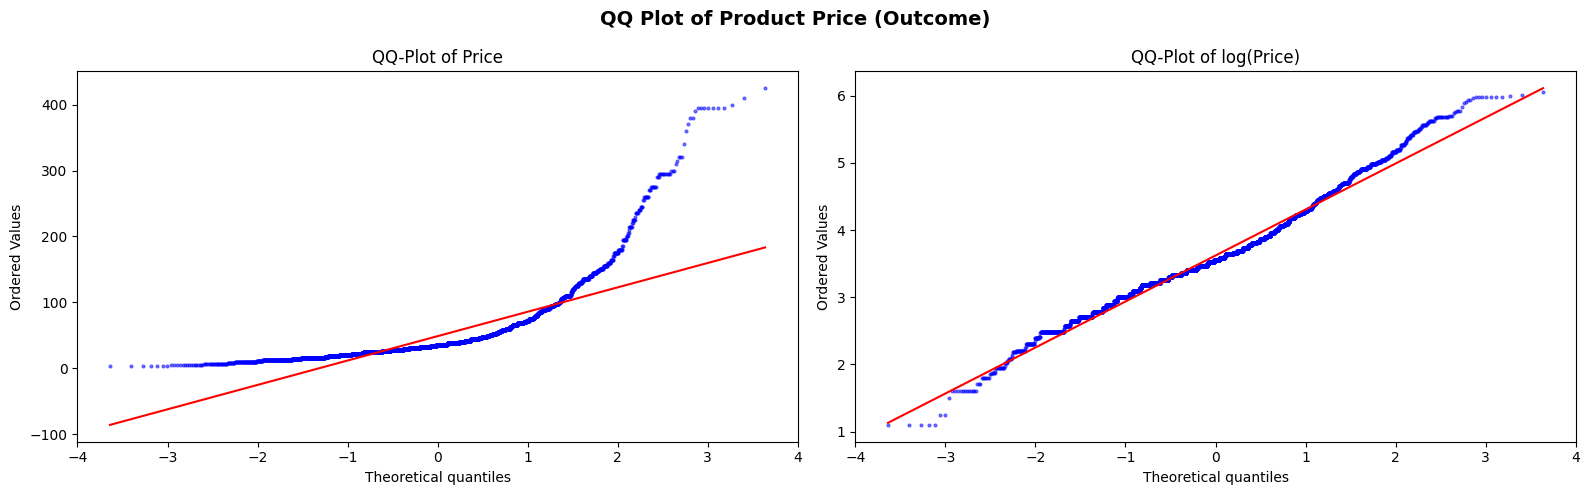

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("QQ Plot of Product Price (Outcome)", fontsize=14, fontweight="bold")
stats.probplot(new_products["price_usd"].dropna(), dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot of Price")
axes[0].get_lines()[0].set(color='blue', markersize=2, alpha=0.5)
axes[0].get_lines()[1].set(color='red')

stats.probplot(np.log(new_products["price_usd"]).dropna(), dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot of log(Price)")
axes[1].get_lines()[0].set(color='blue', markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color='red')

plt.tight_layout()

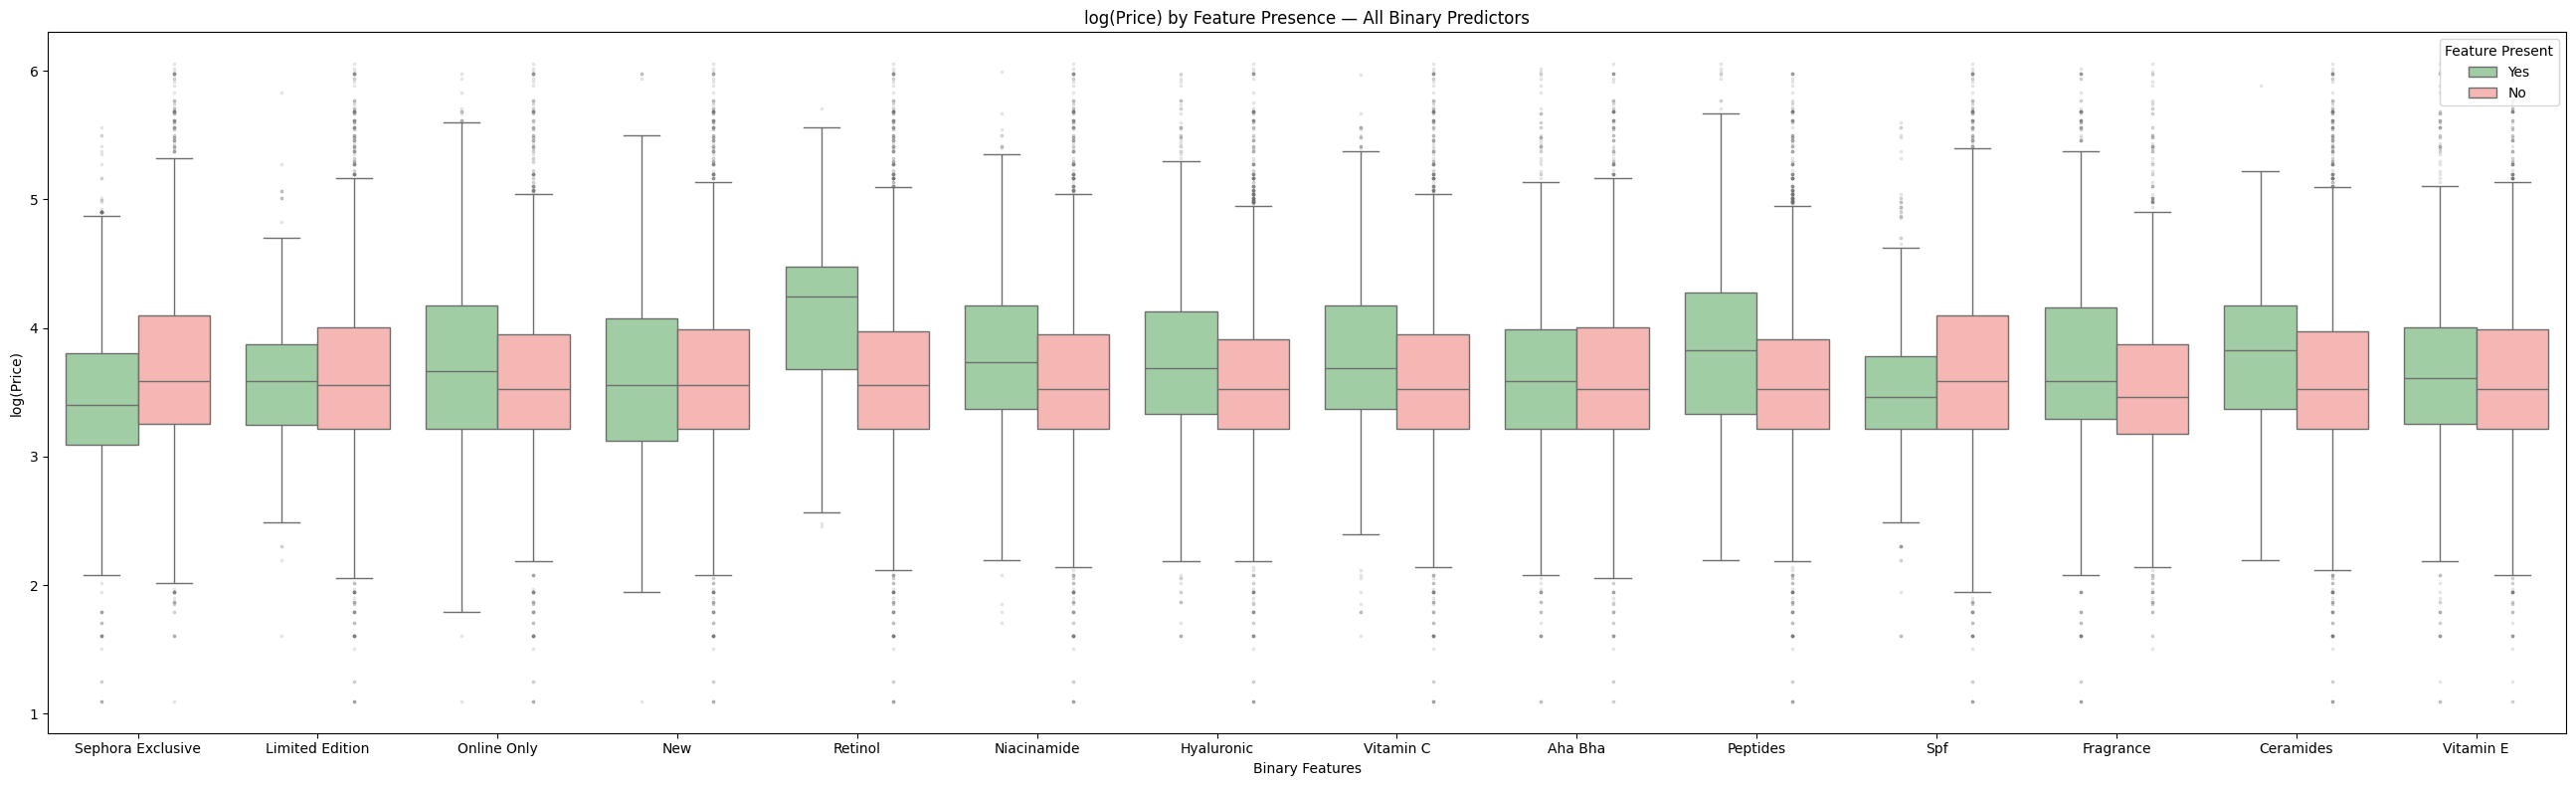

In [23]:
# Price by binary features
bin_cols = [
    "sephora_exclusive", "limited_edition", "online_only", "new",
    "has_retinol", "has_niacinamide", "has_hyaluronic", "has_vitamin_c",
    "has_aha_bha", "has_peptides", "has_spf", "has_fragrance",
    "has_ceramides", "has_vitamin_e"
]

# Melt to long format: one row per product × feature combination
long_df = pd.melt(
    new_products[bin_cols + ['log_price']],
    id_vars="log_price",
    var_name="feature",
    value_name="present"
)
long_df["present"] = long_df["present"].map({1: "Yes", 0: "No"})
long_df["feature"] = long_df["feature"].str.replace("has_", "").str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(26, 8))
sns.boxplot(
    data=long_df, x="feature", y="log_price", hue="present",
    hue_order=["Yes", "No"],
    palette= ['#9ad49f', '#ffada9'],
    flierprops={"marker": ".", "alpha": 0.2, "markersize": 3},
    ax=ax
)
ax.set(title="log(Price) by Feature Presence — All Binary Predictors",
       xlabel="Binary Features", ylabel="log(Price)")

ax.legend(title="Feature Present", loc="upper right")
plt.tight_layout()

/var/folders/z0/pslqf_691f94wn6r6l2rvjgm0000gn/T/ipykernel_14160/4039313385.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


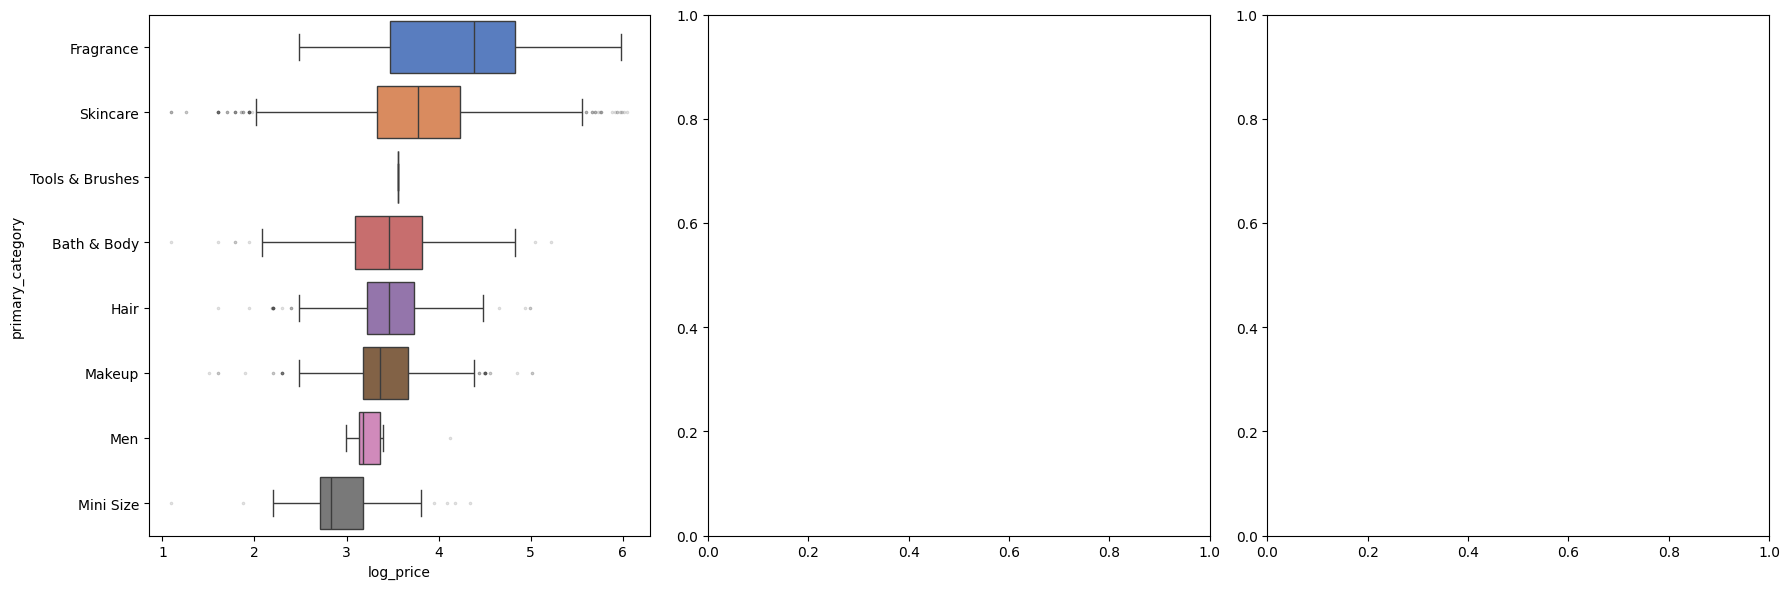

In [26]:
# Price by categorical features
cat_cols = ["primary_category"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, cat_cols):
    order = (new_products.groupby(col)["log_price"]
               .median()
               .sort_values(ascending=False)
               .index)

    sns.boxplot(
        data=new_products, x="log_price", y=col,
        order=order, palette="muted", ax=ax,
        flierprops={"marker": ".", "alpha": 0.2, "markersize": 3},
        orient = 'h'
    )

plt.tight_layout()
plt.show()


      High correlations (|r| > 0.30) — watch for VIF issues:
   var1          var2        r
size_ml has_fragrance 0.305566


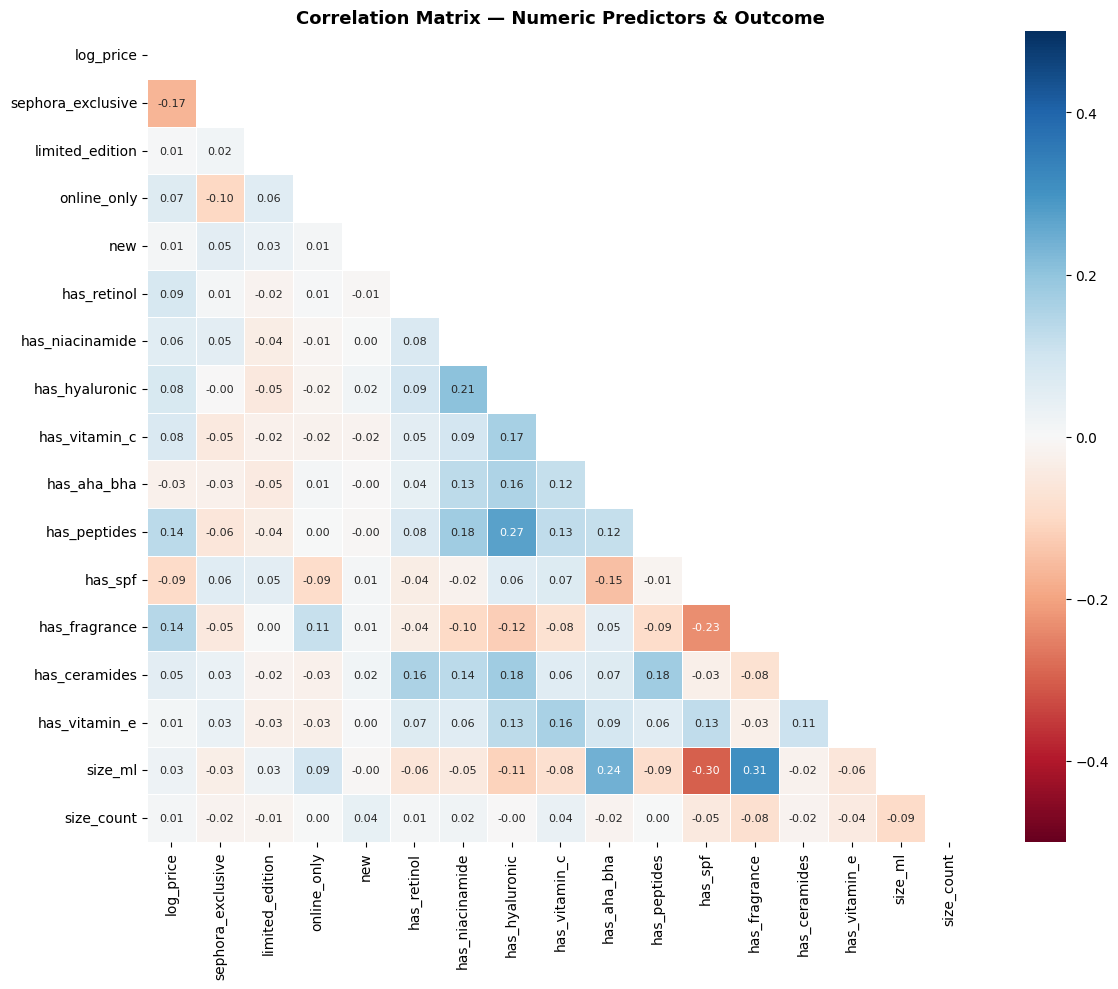

In [27]:
# Correlation Heatmap
numeric_cols = (
    ["log_price"]
    + bin_cols + ["size_ml", "size_count"]
)
numeric_cols = [c for c in numeric_cols if c in new_products.columns]
corr = new_products[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu",
    center=0, vmin=-0.5, vmax=0.5, ax=ax,
    linewidths=0.5, annot_kws={"size": 8}
)
ax.set_title("Correlation Matrix — Numeric Predictors & Outcome", fontsize=13, fontweight="bold")
plt.tight_layout()

# Print high correlations (|r| > 0.3) — potential multicollinearity
high_corr = (corr.abs()
                .where(mask == False)
                .stack()
                .reset_index()
                .rename(columns={0: "r", "level_0": "var1", "level_1": "var2"}))
high_corr = high_corr[
    (high_corr["var1"] != high_corr["var2"]) &
    (high_corr["r"] > 0.30)
].sort_values("r", ascending=False)
if len(high_corr) > 0:
    print(f"\n      High correlations (|r| > 0.30) — watch for VIF issues:")
    print(high_corr.to_string(index=False))

# Modeling

[Text(0, 3, '1706'),
 Text(0, 3, '1218'),
 Text(0, 3, '984'),
 Text(0, 3, '702'),
 Text(0, 3, '246'),
 Text(0, 3, '200')]

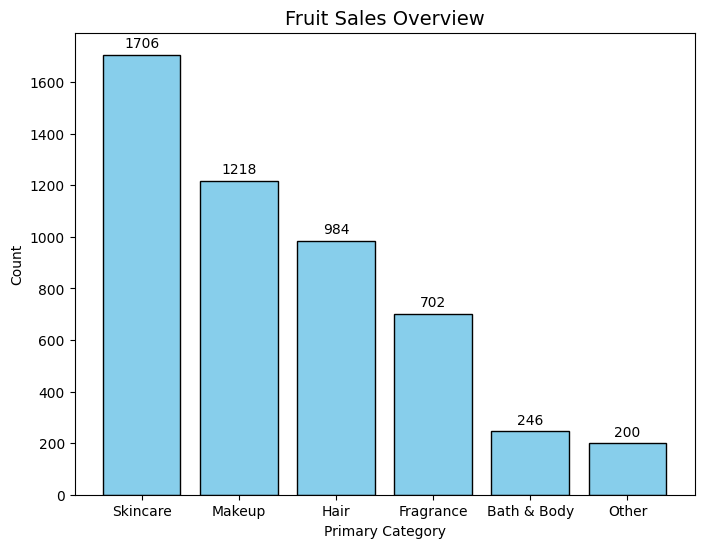

In [29]:
# Justification for using skincare as the baseline
new_products['primary_category'] = new_products['primary_category'].replace({
    'Men': 'Other',
    'Tools & Brushes': 'Other',
    'Mini Size': 'Other'  # optional, debatable
})


# 1. Count the occurrences of each category
category_counts = new_products["primary_category"].value_counts()


# 2. Create fig and ax objects
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Create the bar plot on the 'ax' object
bars = ax.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')

# 4. Customize the plot using 'ax' methods
ax.set_title('Fruit Sales Overview', fontsize=14)
ax.set_xlabel('Primary Category')
ax.set_ylabel('Count')

# Optional: Add data labels on top of bars
ax.bar_label(bars, padding=3)


In [30]:
# What % of Fragrance category products have has_fragrance = 1?
new_products.groupby('primary_category')['has_fragrance'].mean()

primary_category
Bath & Body    0.512195
Fragrance      0.839031
Hair           0.864837
Makeup         0.197865
Other          0.375000
Skincare       0.315358
Name: has_fragrance, dtype: float64

In [31]:
new_products.to_csv("../data/new_products.csv")